In [1]:
# Imports and setup
import json
import numpy as np
from pathlib import Path


In [2]:
# Configuration
base_path_sam = "/home/esli/GenParticles_NeurIPS/final_cvpr_results/TAPVID_subsampling_dense_eval_SAM"
base_path_no_sam = "/home/esli/GenParticles_NeurIPS/final_cvpr_results/TAPVID_subsampling_dense_eval_no_SAM"
cotracker_path = Path("/home/esli/GenParticles_NeurIPS/cotracker_baseline/cotracker_TAPVID_even_init")

subsample_dirs = {
    "subsample_12_5": 12.5,
    "subsample_6_25": 6.25,
    "subsample_3_125": 3.125,
    "subsample_1_5625": 1.5625,
    "subsample_0_78125": 0.78125,
    "subsample_0_390625": 0.390625,
    "subsample_0_1953125": 0.1953125,
    "subsample_0_09765625": 0.09765625,
}
sorted_dirs = sorted(subsample_dirs.items(), key=lambda x: x[1], reverse=True)

In [3]:
# Comprehensive comparison table: SAM vs NO_SAM (Means ± Standard Deviations)
def get_means_and_stds(base_path):
    results = {}
    for dir_name, percentage in sorted_dirs:
        json_results_dir = Path(base_path) / dir_name / "json_results"
        if not json_results_dir.exists():
            continue
        
        jaccard_values = []
        fps_values = []
        json_files = sorted(json_results_dir.glob("*_results.json"))
        for json_file in json_files:
            try:
                with open(json_file, 'r') as f:
                    data = json.load(f)
                if 'pixel_metrics' in data and 'avg_matter_weighted_jaccard_fixed' in data['pixel_metrics']:
                    jaccard = data['pixel_metrics']['avg_matter_weighted_jaccard_fixed']
                    jaccard_values.append(jaccard)
                fps = data.get('fps')
                if fps is not None:
                    fps_values.append(fps)
            except:
                continue
        
        if jaccard_values:
            results[percentage] = {
                'jaccard_mean': np.mean(jaccard_values),
                'jaccard_std': np.std(jaccard_values),
                'fps_mean': np.mean(fps_values) if fps_values else None,
                'fps_std': np.std(fps_values) if fps_values else None
            }
    return results

sam_data = get_means_and_stds(base_path_sam)
no_sam_data = get_means_and_stds(base_path_no_sam)
common_pcts = sorted(set(sam_data.keys()) & set(no_sam_data.keys()))

print("=" * 180)
print("COMPREHENSIVE COMPARISON: SAM vs NO_SAM (Means ± Standard Deviations)")
print("=" * 180)
print(f"{'Subsample %':<15} {'SAM Jaccard':<20} {'SAM FPS':<15} {'NO_SAM Jaccard':<20} {'NO_SAM FPS':<15} {'Jaccard Diff':<15} {'Improvement %':<15}")
print("-" * 180)

all_sam_jaccard = []
all_no_sam_jaccard = []
all_sam_jaccard_std = []
all_no_sam_jaccard_std = []
all_sam_fps = []
all_no_sam_fps = []
all_sam_fps_std = []
all_no_sam_fps_std = []
all_diffs = []
all_improvements = []

for pct in common_pcts:
    sam_jaccard = sam_data[pct]['jaccard_mean']
    sam_jaccard_std = sam_data[pct]['jaccard_std']
    sam_fps = sam_data[pct]['fps_mean']
    sam_fps_std = sam_data[pct]['fps_std']
    no_sam_jaccard = no_sam_data[pct]['jaccard_mean']
    no_sam_jaccard_std = no_sam_data[pct]['jaccard_std']
    no_sam_fps = no_sam_data[pct]['fps_mean']
    no_sam_fps_std = no_sam_data[pct]['fps_std']
    diff = sam_jaccard - no_sam_jaccard
    improvement = (diff / no_sam_jaccard) * 100 if no_sam_jaccard > 0 else 0
    
    all_sam_jaccard.append(sam_jaccard)
    all_no_sam_jaccard.append(no_sam_jaccard)
    all_sam_jaccard_std.append(sam_jaccard_std)
    all_no_sam_jaccard_std.append(no_sam_jaccard_std)
    if sam_fps is not None:
        all_sam_fps.append(sam_fps)
        all_sam_fps_std.append(sam_fps_std)
    if no_sam_fps is not None:
        all_no_sam_fps.append(no_sam_fps)
        all_no_sam_fps_std.append(no_sam_fps_std)
    all_diffs.append(diff)
    all_improvements.append(improvement)
    
    sam_jaccard_str = f"{sam_jaccard:.6f}±{sam_jaccard_std:.6f}"
    no_sam_jaccard_str = f"{no_sam_jaccard:.6f}±{no_sam_jaccard_std:.6f}"
    sam_fps_str = f"{sam_fps:.4f}±{sam_fps_std:.4f}" if sam_fps is not None else "N/A"
    no_sam_fps_str = f"{no_sam_fps:.4f}±{no_sam_fps_std:.4f}" if no_sam_fps is not None else "N/A"
    
    print(f"{pct:<15.4f} {sam_jaccard_str:<20} {sam_fps_str:<15} {no_sam_jaccard_str:<20} {no_sam_fps_str:<15} {diff:<15.6f} {improvement:>+14.2f}%")

print("-" * 180)

overall_sam_jaccard = np.mean(all_sam_jaccard)
overall_no_sam_jaccard = np.mean(all_no_sam_jaccard)
overall_sam_jaccard_std = np.mean(all_sam_jaccard_std)
overall_no_sam_jaccard_std = np.mean(all_no_sam_jaccard_std)
overall_diff = overall_sam_jaccard - overall_no_sam_jaccard
overall_improvement = (overall_diff / overall_no_sam_jaccard) * 100 if overall_no_sam_jaccard > 0 else 0
overall_sam_fps = np.mean(all_sam_fps) if all_sam_fps else None
overall_no_sam_fps = np.mean(all_no_sam_fps) if all_no_sam_fps else None
overall_sam_fps_std = np.mean(all_sam_fps_std) if all_sam_fps_std else None
overall_no_sam_fps_std = np.mean(all_no_sam_fps_std) if all_no_sam_fps_std else None

overall_sam_jaccard_str = f"{overall_sam_jaccard:.6f}±{overall_sam_jaccard_std:.6f}"
overall_no_sam_jaccard_str = f"{overall_no_sam_jaccard:.6f}±{overall_no_sam_jaccard_std:.6f}"
overall_sam_fps_str = f"{overall_sam_fps:.4f}±{overall_sam_fps_std:.4f}" if overall_sam_fps is not None else "N/A"
overall_no_sam_fps_str = f"{overall_no_sam_fps:.4f}±{overall_no_sam_fps_std:.4f}" if overall_no_sam_fps is not None else "N/A"

print(f"{'OVERALL AVERAGE':<15} {overall_sam_jaccard_str:<20} {overall_sam_fps_str:<15} {overall_no_sam_jaccard_str:<20} {overall_no_sam_fps_str:<15} {overall_diff:<15.6f} {overall_improvement:>+14.2f}%")
print("=" * 180)

# CoTracker baseline
cotracker_jaccard_values = []
if cotracker_path.exists():
    json_files = sorted(cotracker_path.glob("*_results.json"))
    for json_file in json_files:
        try:
            with open(json_file, 'r') as f:
                data = json.load(f)
            jaccard = None
            if 'mean_jaccard' in data:
                jaccard = data['mean_jaccard']
            elif 'pixel_metrics' in data and 'avg_matter_weighted_jaccard_fixed' in data['pixel_metrics']:
                jaccard = data['pixel_metrics']['avg_matter_weighted_jaccard_fixed']
            elif 'jaccard_scores' in data and len(data['jaccard_scores']) > 0:
                jaccard = np.mean(data['jaccard_scores'])
            if jaccard is not None:
                cotracker_jaccard_values.append(jaccard)
        except:
            continue

if cotracker_jaccard_values:
    cotracker_mean = np.mean(cotracker_jaccard_values)
    cotracker_std = np.std(cotracker_jaccard_values)
    cotracker_str = f"{cotracker_mean:.6f}±{cotracker_std:.6f}"
    print("\n" + "=" * 180)
    print("COTRACKER BASELINE")
    print("=" * 180)
    print(f"{'Method':<15} {'Jaccard Accuracy':<20} {'# Videos':<10}")
    print("-" * 180)
    print(f"{'CoTracker':<15} {cotracker_str:<20} {len(cotracker_jaccard_values):<10}")
    print("=" * 180)


COMPREHENSIVE COMPARISON: SAM vs NO_SAM (Means ± Standard Deviations)
Subsample %     SAM Jaccard          SAM FPS         NO_SAM Jaccard       NO_SAM FPS      Jaccard Diff    Improvement %  
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
0.1953          0.559332±0.254449    9.3147±2.3549   0.543624±0.255098    9.7266±2.4988   0.015709                 +2.89%
0.3906          0.716695±0.213317    9.5284±2.5104   0.716322±0.152789    9.9363±2.6060   0.000373                 +0.05%
0.7812          0.787496±0.151121    9.3908±2.5351   0.770456±0.173073    9.8332±2.5530   0.017041                 +2.21%
1.5625          0.785049±0.157896    9.1770±2.3568   0.778291±0.160037    9.4849±2.5472   0.006758                 +0.87%
3.1250          0.777633±0.154827    8.6495±2.1104   0.781373±0.139136    8.9731±2.1532   -0.003740                -0.48%
6.2500          0

In [4]:
# Process FPS data across all subsample directories (NO_SAM version)
# Read FPS from individual JSON files in json_results directory
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

base_path_no_sam = "/home/esli/GenParticles_NeurIPS/final_cvpr_results/TAPVID_subsampling_dense_eval_no_SAM"

# Map directory names to subsample percentages
subsample_dirs = {
    "subsample_12_5": 12.5,        # 1/8
    "subsample_6_25": 6.25,        # 1/16
    "subsample_3_125": 3.125,      # 1/32
    "subsample_1_5625": 1.5625,    # 1/64
    "subsample_0_78125": 0.78125,  # 1/128
    "subsample_0_390625": 0.390625,  # 1/256
    "subsample_0_1953125": 0.1953125,  # 1/512
    "subsample_0_09765625": 0.09765625,  # 1/1024
}

# Sort by percentage (descending)
sorted_dirs = sorted(subsample_dirs.items(), key=lambda x: x[1], reverse=True)

fps_means = []
fps_stds = []
subsample_percentages = []

print("Processing FPS data for each subsample directory (NO_SAM version):\n")
print(f"{'Directory':<25} {'Subsample %':<15} {'Avg FPS':<12} {'Std FPS':<12} {'# Videos':<10}")
print("=" * 80)

for dir_name, percentage in sorted_dirs:
    json_results_dir = Path(base_path_no_sam) / dir_name / "json_results"
    
    if not json_results_dir.exists():
        print(f"Warning: {json_results_dir} not found, skipping...")
        continue
    
    # Read FPS from individual JSON files
    fps_values = []
    json_files = sorted(json_results_dir.glob("*_results.json"))
    
    for json_file in json_files:
        try:
            with open(json_file, 'r') as f:
                data = json.load(f)
            fps = data.get('fps')
            if fps is not None:
                fps_values.append(fps)
        except Exception as e:
            print(f"Warning: Error reading {json_file}: {e}")
            continue
    
    if fps_values:
        avg_fps = np.mean(fps_values)
        std_fps = np.std(fps_values)
        fps_means.append(avg_fps)
        fps_stds.append(std_fps)
        subsample_percentages.append(percentage)
        print(f"{dir_name:<25} {percentage:<15.4f} {avg_fps:<12.4f} {std_fps:<12.4f} {len(fps_values):<10}")
    else:
        print(f"{dir_name:<25} {percentage:<15.4f} {'No FPS data':<12}")

print("\n" + "=" * 80)


Processing FPS data for each subsample directory (NO_SAM version):

Directory                 Subsample %     Avg FPS      Std FPS      # Videos  
subsample_12_5            12.5000         6.4751       1.1393       30        
subsample_6_25            6.2500          7.9893       1.7259       30        
subsample_3_125           3.1250          8.9731       2.1532       30        
subsample_1_5625          1.5625          9.4849       2.5472       30        
subsample_0_78125         0.7812          9.8332       2.5530       30        
subsample_0_390625        0.3906          9.9363       2.6060       30        
subsample_0_1953125       0.1953          9.7266       2.4988       30        



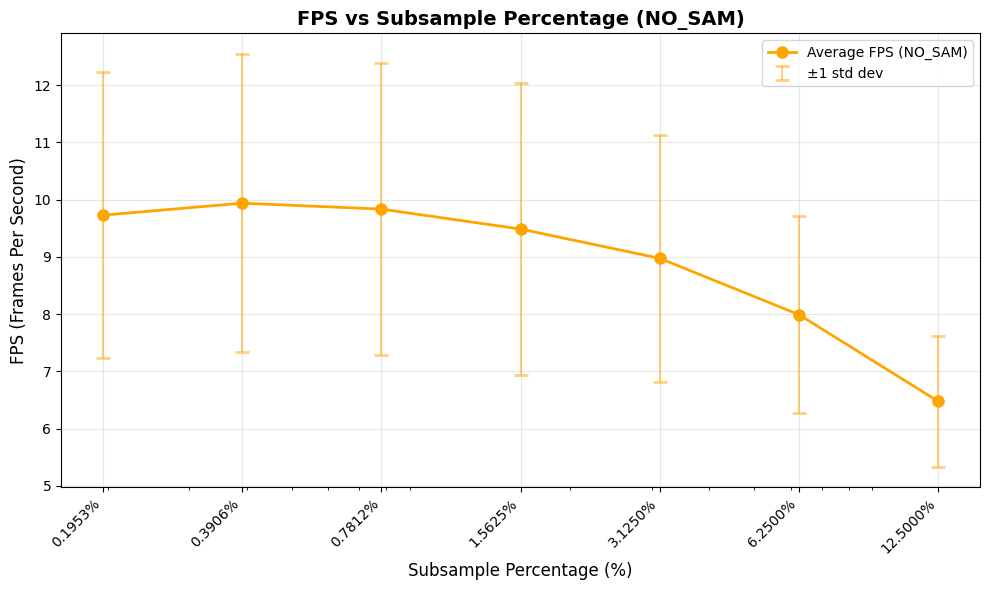


Summary (NO_SAM):
Highest FPS: 9.9363 at 0.3906%
Lowest FPS: 6.4751 at 12.5000%
FPS range: 3.4612


In [5]:
# Plot FPS vs subsample percentage (NO_SAM version)
plt.figure(figsize=(10, 6))
plt.plot(subsample_percentages, fps_means, 'o-', linewidth=2, markersize=8, label='Average FPS (NO_SAM)', color='orange')
plt.errorbar(subsample_percentages, fps_means, yerr=fps_stds, fmt='none', 
             capsize=5, capthick=2, alpha=0.5, label='±1 std dev', color='orange')

plt.xlabel('Subsample Percentage (%)', fontsize=12)
plt.ylabel('FPS (Frames Per Second)', fontsize=12)
plt.title('FPS vs Subsample Percentage (NO_SAM)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)

# Set x-axis to log scale for better visualization
plt.xscale('log')
plt.xticks(subsample_percentages, [f'{p:.4f}%' for p in subsample_percentages], rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Print summary
print(f"\nSummary (NO_SAM):")
print(f"Highest FPS: {max(fps_means):.4f} at {subsample_percentages[fps_means.index(max(fps_means))]:.4f}%")
print(f"Lowest FPS: {min(fps_means):.4f} at {subsample_percentages[fps_means.index(min(fps_means))]:.4f}%")
print(f"FPS range: {max(fps_means) - min(fps_means):.4f}")


Calculating averages per subsample directory (NO_SAM)...

Directory                 Subsample %     Avg FPS      Avg Jaccard     # Videos  
subsample_12_5            12.5000         6.4751       0.779140        30        
subsample_6_25            6.2500          7.9893       0.770130        30        
subsample_3_125           3.1250          8.9731       0.781373        30        
subsample_1_5625          1.5625          9.4849       0.778291        30        
subsample_0_78125         0.7812          9.8332       0.770456        30        
subsample_0_390625        0.3906          9.9363       0.716322        30        
subsample_0_1953125       0.1953          9.7266       0.543624        30        



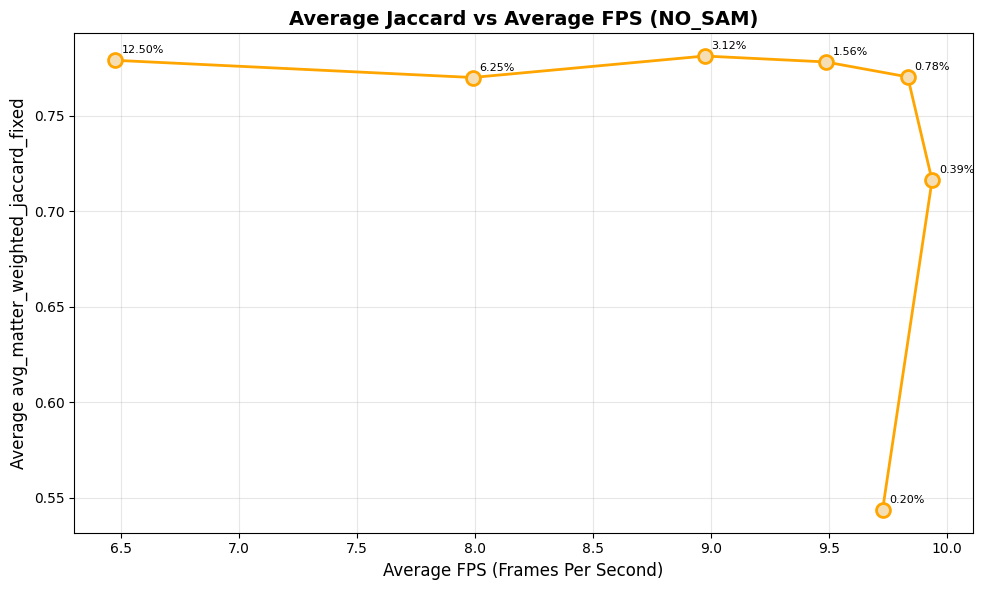


Summary (NO_SAM):
FPS range: 6.4751 - 9.9363
Jaccard range: 0.543624 - 0.781373
Correlation: -0.3840


In [6]:
# Plot average Jaccard vs average FPS (NO_SAM version)
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

base_path_no_sam = "/home/esli/GenParticles_NeurIPS/final_cvpr_results/TAPVID_subsampling_dense_eval_no_SAM"

# Map directory names to subsample percentages
subsample_dirs = {
    "subsample_12_5": 12.5,        # 1/8
    "subsample_6_25": 6.25,        # 1/16
    "subsample_3_125": 3.125,      # 1/32
    "subsample_1_5625": 1.5625,    # 1/64
    "subsample_0_78125": 0.78125,  # 1/128
    "subsample_0_390625": 0.390625,  # 1/256
    "subsample_0_1953125": 0.1953125,  # 1/512
    "subsample_0_09765625": 0.09765625,  # 1/1024
}

# Sort by percentage (descending)
sorted_dirs = sorted(subsample_dirs.items(), key=lambda x: x[1], reverse=True)

avg_fps_list = []
avg_jaccard_list = []
subsample_percentages = []

print("Calculating averages per subsample directory (NO_SAM)...\n")
print(f"{'Directory':<25} {'Subsample %':<15} {'Avg FPS':<12} {'Avg Jaccard':<15} {'# Videos':<10}")
print("=" * 80)

for dir_name, percentage in sorted_dirs:
    json_results_dir = Path(base_path_no_sam) / dir_name / "json_results"
    
    if not json_results_dir.exists():
        print(f"Warning: {json_results_dir} not found, skipping...")
        continue
    
    fps_values = []
    jaccard_values = []
    
    json_files = sorted(json_results_dir.glob("*_results.json"))
    
    for json_file in json_files:
        try:
            with open(json_file, 'r') as f:
                data = json.load(f)
            
            fps = data.get('fps')
            jaccard = None
            if 'pixel_metrics' in data and 'avg_matter_weighted_jaccard_fixed' in data['pixel_metrics']:
                jaccard = data['pixel_metrics']['avg_matter_weighted_jaccard_fixed']
            
            if fps is not None and jaccard is not None:
                fps_values.append(fps)
                jaccard_values.append(jaccard)
        except Exception as e:
            print(f"Warning: Error reading {json_file}: {e}")
            continue
    
    if fps_values and jaccard_values:
        avg_fps = np.mean(fps_values)
        avg_jaccard = np.mean(jaccard_values)
        avg_fps_list.append(avg_fps)
        avg_jaccard_list.append(avg_jaccard)
        subsample_percentages.append(percentage)
        print(f"{dir_name:<25} {percentage:<15.4f} {avg_fps:<12.4f} {avg_jaccard:<15.6f} {len(fps_values):<10}")

print("\n" + "=" * 80)

# Create the line plot
plt.figure(figsize=(10, 6))
plt.plot(avg_fps_list, avg_jaccard_list, 'o-', linewidth=2, markersize=10, 
         color='orange', markerfacecolor='wheat', markeredgewidth=2)

# Add labels for each point
for i, (fps, jaccard, pct) in enumerate(zip(avg_fps_list, avg_jaccard_list, subsample_percentages)):
    plt.annotate(f'{pct:.2f}%', (fps, jaccard), 
                textcoords="offset points", xytext=(5, 5), ha='left', fontsize=8)

plt.xlabel('Average FPS (Frames Per Second)', fontsize=12)
plt.ylabel('Average avg_matter_weighted_jaccard_fixed', fontsize=12)
plt.title('Average Jaccard vs Average FPS (NO_SAM)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print(f"\nSummary (NO_SAM):")
print(f"FPS range: {min(avg_fps_list):.4f} - {max(avg_fps_list):.4f}")
print(f"Jaccard range: {min(avg_jaccard_list):.6f} - {max(avg_jaccard_list):.6f}")
print(f"Correlation: {np.corrcoef(avg_fps_list, avg_jaccard_list)[0, 1]:.4f}")


In [7]:
# Find which video is missing (NO_SAM version)
import json
from pathlib import Path
from collections import defaultdict

base_path_no_sam = "/home/esli/GenParticles_NeurIPS/final_cvpr_results/TAPVID_subsampling_dense_eval_no_SAM"

# Map directory names to subsample percentages
subsample_dirs = {
    "subsample_12_5": 12.5,
    "subsample_6_25": 6.25,
    "subsample_3_125": 3.125,
    "subsample_1_5625": 1.5625,
    "subsample_0_78125": 0.78125,
    "subsample_0_390625": 0.390625,
    "subsample_0_1953125": 0.1953125,
    "subsample_0_09765625": 0.09765625,
}

# Collect all videos from each directory
videos_by_dir = {}
all_videos = set()

for dir_name, percentage in subsample_dirs.items():
    json_results_dir = Path(base_path_no_sam) / dir_name / "json_results"
    
    if not json_results_dir.exists():
        print(f"Warning: {json_results_dir} not found, skipping...")
        continue
    
    json_files = sorted(json_results_dir.glob("*_results.json"))
    video_names = set()
    
    for json_file in json_files:
        video_name = json_file.stem.replace("_results", "")
        video_names.add(video_name)
        all_videos.add(video_name)
    
    videos_by_dir[dir_name] = video_names
    print(f"{dir_name}: {len(video_names)} videos")

print(f"\nTotal unique videos across all directories (NO_SAM): {len(all_videos)}")
print("\n" + "=" * 80)
print("Missing videos per directory (NO_SAM):")
print("=" * 80)

# Find which videos are missing in each directory
for dir_name, video_set in videos_by_dir.items():
    missing = all_videos - video_set
    if missing:
        print(f"{dir_name}: Missing {missing}")
    else:
        print(f"{dir_name}: All videos present")

# Find videos that are in the highest percentage directory but missing in others
# Use the directory with the highest percentage (subsample_12_5) as reference
if "subsample_12_5" in videos_by_dir:
    videos_ref = videos_by_dir["subsample_12_5"]
    print("\n" + "=" * 80)
    print("Videos in subsample_12_5 but missing in other directories (NO_SAM):")
    print("=" * 80)
    
    for dir_name, video_set in videos_by_dir.items():
        if dir_name != "subsample_12_5":
            missing_from_this = videos_ref - video_set
            if missing_from_this:
                print(f"Missing from {dir_name}: {missing_from_this}")


subsample_12_5: 30 videos
subsample_6_25: 30 videos
subsample_3_125: 30 videos
subsample_1_5625: 30 videos
subsample_0_78125: 30 videos
subsample_0_390625: 30 videos
subsample_0_1953125: 30 videos

Total unique videos across all directories (NO_SAM): 30

Missing videos per directory (NO_SAM):
subsample_12_5: All videos present
subsample_6_25: All videos present
subsample_3_125: All videos present
subsample_1_5625: All videos present
subsample_0_78125: All videos present
subsample_0_390625: All videos present
subsample_0_1953125: All videos present

Videos in subsample_12_5 but missing in other directories (NO_SAM):


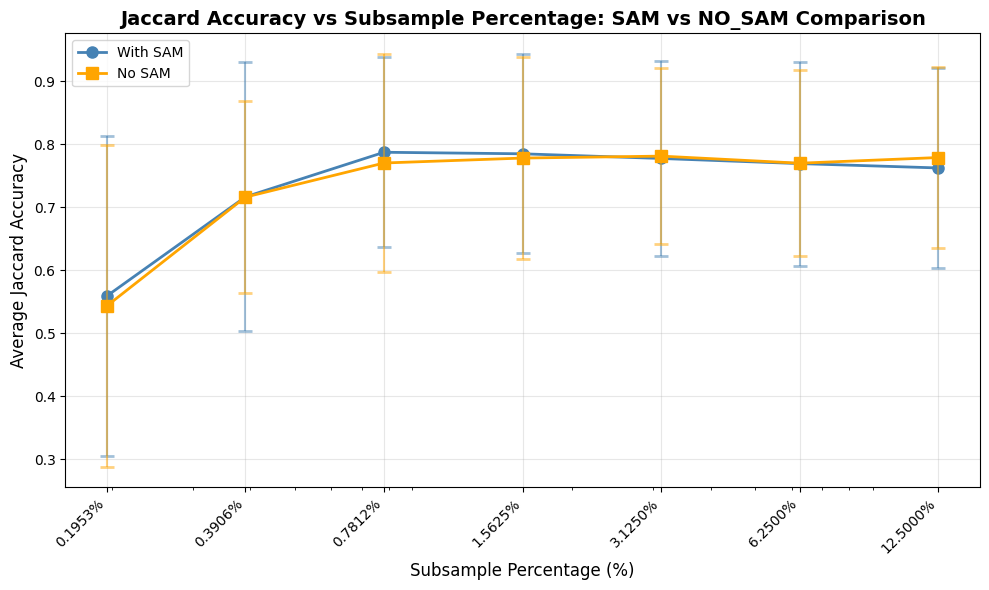


Accuracy Comparison Summary:
SAM - Jaccard range: 0.559332 - 0.787496
NO_SAM - Jaccard range: 0.543624 - 0.781373
Average difference (SAM - NO_SAM): 0.002709


In [8]:
# Comparison plot: SAM vs NO_SAM - Jaccard Accuracy vs Subsample Percentage
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

base_path_sam = "/home/esli/GenParticles_NeurIPS/final_cvpr_results/TAPVID_subsampling_dense_eval_SAM"
base_path_no_sam = "/home/esli/GenParticles_NeurIPS/final_cvpr_results/TAPVID_subsampling_dense_eval_no_SAM"

subsample_dirs = {
    "subsample_12_5": 12.5,
    "subsample_6_25": 6.25,
    "subsample_3_125": 3.125,
    "subsample_1_5625": 1.5625,
    "subsample_0_78125": 0.78125,
    "subsample_0_390625": 0.390625,
    "subsample_0_1953125": 0.1953125,
    "subsample_0_09765625": 0.09765625,
}

sorted_dirs = sorted(subsample_dirs.items(), key=lambda x: x[1], reverse=True)

def get_jaccard_data(base_path):
    jaccard_means = []
    jaccard_stds = []
    percentages = []
    
    for dir_name, percentage in sorted_dirs:
        json_results_dir = Path(base_path) / dir_name / "json_results"
        if not json_results_dir.exists():
            continue
        
        jaccard_values = []
        json_files = sorted(json_results_dir.glob("*_results.json"))
        for json_file in json_files:
            try:
                with open(json_file, 'r') as f:
                    data = json.load(f)
                if 'pixel_metrics' in data and 'avg_matter_weighted_jaccard_fixed' in data['pixel_metrics']:
                    jaccard = data['pixel_metrics']['avg_matter_weighted_jaccard_fixed']
                    jaccard_values.append(jaccard)
            except:
                continue
        
        if jaccard_values:
            jaccard_means.append(np.mean(jaccard_values))
            jaccard_stds.append(np.std(jaccard_values))
            percentages.append(percentage)
    
    return percentages, jaccard_means, jaccard_stds

pct_sam, jaccard_sam, std_sam = get_jaccard_data(base_path_sam)
pct_no_sam, jaccard_no_sam, std_no_sam = get_jaccard_data(base_path_no_sam)

plt.figure(figsize=(10, 6))
plt.plot(pct_sam, jaccard_sam, 'o-', linewidth=2, markersize=8, label='With SAM', color='steelblue')
plt.errorbar(pct_sam, jaccard_sam, yerr=std_sam, fmt='none', capsize=5, capthick=2, alpha=0.5, color='steelblue')
plt.plot(pct_no_sam, jaccard_no_sam, 's-', linewidth=2, markersize=8, label='No SAM', color='orange')
plt.errorbar(pct_no_sam, jaccard_no_sam, yerr=std_no_sam, fmt='none', capsize=5, capthick=2, alpha=0.5, color='orange')

plt.xlabel('Subsample Percentage (%)', fontsize=12)
plt.ylabel('Average Jaccard Accuracy', fontsize=12)
plt.title('Jaccard Accuracy vs Subsample Percentage: SAM vs NO_SAM Comparison', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.xscale('log')
plt.xticks(pct_sam if len(pct_sam) > 0 else pct_no_sam, 
           [f'{p:.4f}%' for p in (pct_sam if len(pct_sam) > 0 else pct_no_sam)], 
           rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nAccuracy Comparison Summary:")
print(f"SAM - Jaccard range: {min(jaccard_sam):.6f} - {max(jaccard_sam):.6f}")
print(f"NO_SAM - Jaccard range: {min(jaccard_no_sam):.6f} - {max(jaccard_no_sam):.6f}")
print(f"Average difference (SAM - NO_SAM): {np.mean(jaccard_sam) - np.mean(jaccard_no_sam):.6f}")


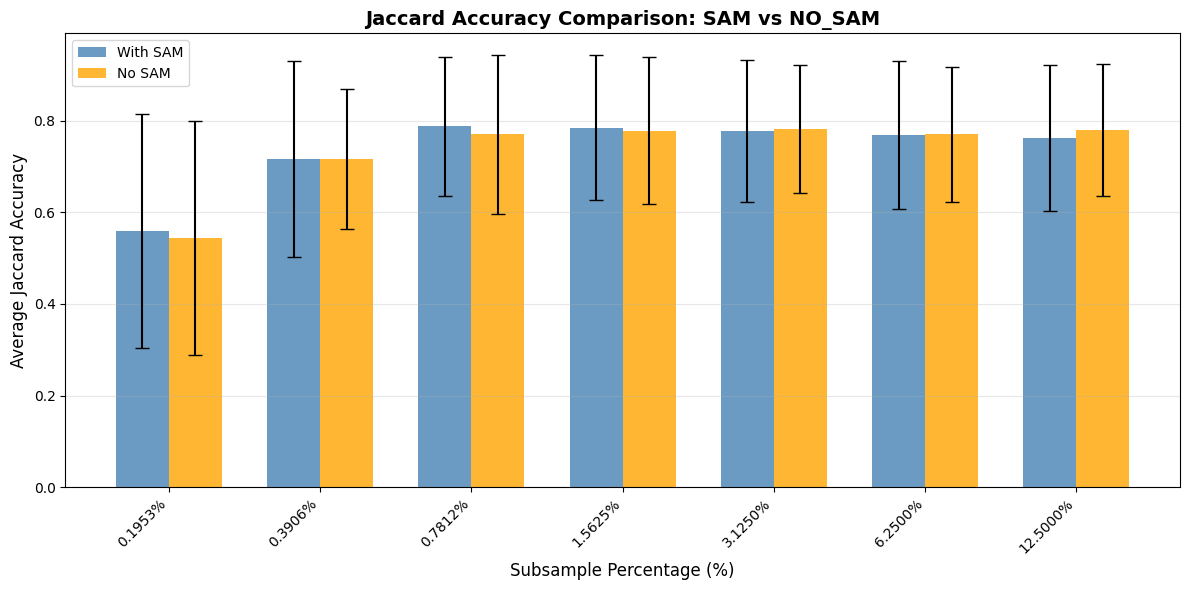


Detailed Accuracy Comparison:
Subsample %     SAM Mean     NO_SAM Mean  Difference   Improvement 
0.1953          0.559332     0.543624     0.015709           +2.89%
0.3906          0.716695     0.716322     0.000373           +0.05%
0.7812          0.787496     0.770456     0.017041           +2.21%
1.5625          0.785049     0.778291     0.006758           +0.87%
3.1250          0.777633     0.781373     -0.003740          -0.48%
6.2500          0.769505     0.770130     -0.000625          -0.08%
12.5000         0.762587     0.779140     -0.016553          -2.12%
Overall Average 0.736900     0.734191     0.002709           +0.37%


In [9]:
# Direct accuracy comparison: SAM vs NO_SAM at each subsample percentage
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

base_path_sam = "/home/esli/GenParticles_NeurIPS/final_cvpr_results/TAPVID_subsampling_dense_eval_SAM"
base_path_no_sam = "/home/esli/GenParticles_NeurIPS/final_cvpr_results/TAPVID_subsampling_dense_eval_no_SAM"

subsample_dirs = {
    "subsample_12_5": 12.5,
    "subsample_6_25": 6.25,
    "subsample_3_125": 3.125,
    "subsample_1_5625": 1.5625,
    "subsample_0_78125": 0.78125,
    "subsample_0_390625": 0.390625,
    "subsample_0_1953125": 0.1953125,
    "subsample_0_09765625": 0.09765625,
}

sorted_dirs = sorted(subsample_dirs.items(), key=lambda x: x[1], reverse=True)

def get_jaccard_data(base_path):
    results = {}
    for dir_name, percentage in sorted_dirs:
        json_results_dir = Path(base_path) / dir_name / "json_results"
        if not json_results_dir.exists():
            continue
        
        jaccard_values = []
        json_files = sorted(json_results_dir.glob("*_results.json"))
        for json_file in json_files:
            try:
                with open(json_file, 'r') as f:
                    data = json.load(f)
                if 'pixel_metrics' in data and 'avg_matter_weighted_jaccard_fixed' in data['pixel_metrics']:
                    jaccard = data['pixel_metrics']['avg_matter_weighted_jaccard_fixed']
                    jaccard_values.append(jaccard)
            except:
                continue
        
        if jaccard_values:
            results[percentage] = {
                'mean': np.mean(jaccard_values),
                'std': np.std(jaccard_values),
                'values': jaccard_values
            }
    
    return results

jaccard_sam = get_jaccard_data(base_path_sam)
jaccard_no_sam = get_jaccard_data(base_path_no_sam)

# Get common percentages
common_pcts = sorted(set(jaccard_sam.keys()) & set(jaccard_no_sam.keys()))

sam_means = [jaccard_sam[p]['mean'] for p in common_pcts]
sam_stds = [jaccard_sam[p]['std'] for p in common_pcts]
no_sam_means = [jaccard_no_sam[p]['mean'] for p in common_pcts]
no_sam_stds = [jaccard_no_sam[p]['std'] for p in common_pcts]

# Create bar plot comparison
x = np.arange(len(common_pcts))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, sam_means, width, yerr=sam_stds, label='With SAM', 
               color='steelblue', alpha=0.8, capsize=5)
bars2 = ax.bar(x + width/2, no_sam_means, width, yerr=no_sam_stds, label='No SAM', 
               color='orange', alpha=0.8, capsize=5)

ax.set_xlabel('Subsample Percentage (%)', fontsize=12)
ax.set_ylabel('Average Jaccard Accuracy', fontsize=12)
ax.set_title('Jaccard Accuracy Comparison: SAM vs NO_SAM', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'{p:.4f}%' for p in common_pcts], rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print detailed comparison
print(f"\nDetailed Accuracy Comparison:")
print(f"{'Subsample %':<15} {'SAM Mean':<12} {'NO_SAM Mean':<12} {'Difference':<12} {'Improvement':<12}")
print("=" * 70)
for pct in common_pcts:
    sam_mean = jaccard_sam[pct]['mean']
    no_sam_mean = jaccard_no_sam[pct]['mean']
    diff = sam_mean - no_sam_mean
    improvement = (diff / no_sam_mean) * 100 if no_sam_mean > 0 else 0
    print(f"{pct:<15.4f} {sam_mean:<12.6f} {no_sam_mean:<12.6f} {diff:<12.6f} {improvement:>+11.2f}%")

overall_diff = np.mean(sam_means) - np.mean(no_sam_means)
overall_improvement = (overall_diff / np.mean(no_sam_means)) * 100
print("=" * 70)
print(f"{'Overall Average':<15} {np.mean(sam_means):<12.6f} {np.mean(no_sam_means):<12.6f} {overall_diff:<12.6f} {overall_improvement:>+11.2f}%")


In [10]:
# Final comprehensive comparison table: SAM vs NO_SAM (Means only)
import json
import numpy as np
from pathlib import Path

base_path_sam = "/home/esli/GenParticles_NeurIPS/final_cvpr_results/TAPVID_subsampling_dense_eval_SAM"
base_path_no_sam = "/home/esli/GenParticles_NeurIPS/final_cvpr_results/TAPVID_subsampling_dense_eval_no_SAM"

subsample_dirs = {
    "subsample_12_5": 12.5,
    "subsample_6_25": 6.25,
    "subsample_3_125": 3.125,
    "subsample_1_5625": 1.5625,
    "subsample_0_78125": 0.78125,
    "subsample_0_390625": 0.390625,
    "subsample_0_1953125": 0.1953125,
    "subsample_0_09765625": 0.09765625,
}

sorted_dirs = sorted(subsample_dirs.items(), key=lambda x: x[1], reverse=True)

def get_means_and_stds(base_path):
    results = {}
    for dir_name, percentage in sorted_dirs:
        json_results_dir = Path(base_path) / dir_name / "json_results"
        if not json_results_dir.exists():
            continue
        
        jaccard_values = []
        fps_values = []
        json_files = sorted(json_results_dir.glob("*_results.json"))
        for json_file in json_files:
            try:
                with open(json_file, 'r') as f:
                    data = json.load(f)
                if 'pixel_metrics' in data and 'avg_matter_weighted_jaccard_fixed' in data['pixel_metrics']:
                    jaccard = data['pixel_metrics']['avg_matter_weighted_jaccard_fixed']
                    jaccard_values.append(jaccard)
                fps = data.get('fps')
                if fps is not None:
                    fps_values.append(fps)
            except:
                continue
        
        if jaccard_values:
            results[percentage] = {
                'jaccard_mean': np.mean(jaccard_values),
                'jaccard_std': np.std(jaccard_values),
                'fps_mean': np.mean(fps_values) if fps_values else None,
                'fps_std': np.std(fps_values) if fps_values else None
            }
    
    return results

sam_data = get_means_and_stds(base_path_sam)
no_sam_data = get_means_and_stds(base_path_no_sam)

# Get common percentages
common_pcts = sorted(set(sam_data.keys()) & set(no_sam_data.keys()))

print("=" * 180)
print("COMPREHENSIVE COMPARISON: SAM vs NO_SAM (Means ± Standard Deviations)")
print("=" * 180)
print(f"{'Subsample %':<15} {'SAM Jaccard':<20} {'SAM FPS':<15} {'NO_SAM Jaccard':<20} {'NO_SAM FPS':<15} {'Jaccard Diff':<15} {'Improvement %':<15}")
print("-" * 180)

all_sam_jaccard = []
all_no_sam_jaccard = []
all_sam_jaccard_std = []
all_no_sam_jaccard_std = []
all_sam_fps = []
all_no_sam_fps = []
all_sam_fps_std = []
all_no_sam_fps_std = []
all_diffs = []
all_improvements = []

for pct in common_pcts:
    sam_jaccard = sam_data[pct]['jaccard_mean']
    sam_jaccard_std = sam_data[pct]['jaccard_std']
    sam_fps = sam_data[pct]['fps_mean']
    sam_fps_std = sam_data[pct]['fps_std']
    no_sam_jaccard = no_sam_data[pct]['jaccard_mean']
    no_sam_jaccard_std = no_sam_data[pct]['jaccard_std']
    no_sam_fps = no_sam_data[pct]['fps_mean']
    no_sam_fps_std = no_sam_data[pct]['fps_std']
    diff = sam_jaccard - no_sam_jaccard
    improvement = (diff / no_sam_jaccard) * 100 if no_sam_jaccard > 0 else 0
    
    all_sam_jaccard.append(sam_jaccard)
    all_no_sam_jaccard.append(no_sam_jaccard)
    all_sam_jaccard_std.append(sam_jaccard_std)
    all_no_sam_jaccard_std.append(no_sam_jaccard_std)
    if sam_fps is not None:
        all_sam_fps.append(sam_fps)
        all_sam_fps_std.append(sam_fps_std)
    if no_sam_fps is not None:
        all_no_sam_fps.append(no_sam_fps)
        all_no_sam_fps_std.append(no_sam_fps_std)
    all_diffs.append(diff)
    all_improvements.append(improvement)
    
    sam_jaccard_str = f"{sam_jaccard:.6f}±{sam_jaccard_std:.6f}"
    no_sam_jaccard_str = f"{no_sam_jaccard:.6f}±{no_sam_jaccard_std:.6f}"
    sam_fps_str = f"{sam_fps:.4f}±{sam_fps_std:.4f}" if sam_fps is not None else "N/A"
    no_sam_fps_str = f"{no_sam_fps:.4f}±{no_sam_fps_std:.4f}" if no_sam_fps is not None else "N/A"
    
    print(f"{pct:<15.4f} {sam_jaccard_str:<20} {sam_fps_str:<15} {no_sam_jaccard_str:<20} {no_sam_fps_str:<15} {diff:<15.6f} {improvement:>+14.2f}%")

print("-" * 180)

# Overall statistics
overall_sam_jaccard = np.mean(all_sam_jaccard)
overall_no_sam_jaccard = np.mean(all_no_sam_jaccard)
overall_sam_jaccard_std = np.mean(all_sam_jaccard_std)  # Average of stds across subsamples
overall_no_sam_jaccard_std = np.mean(all_no_sam_jaccard_std)
overall_diff = overall_sam_jaccard - overall_no_sam_jaccard
overall_improvement = (overall_diff / overall_no_sam_jaccard) * 100 if overall_no_sam_jaccard > 0 else 0
overall_sam_fps = np.mean(all_sam_fps) if all_sam_fps else None
overall_no_sam_fps = np.mean(all_no_sam_fps) if all_no_sam_fps else None
overall_sam_fps_std = np.mean(all_sam_fps_std) if all_sam_fps_std else None
overall_no_sam_fps_std = np.mean(all_no_sam_fps_std) if all_no_sam_fps_std else None

overall_sam_jaccard_str = f"{overall_sam_jaccard:.6f}±{overall_sam_jaccard_std:.6f}"
overall_no_sam_jaccard_str = f"{overall_no_sam_jaccard:.6f}±{overall_no_sam_jaccard_std:.6f}"
overall_sam_fps_str = f"{overall_sam_fps:.4f}±{overall_sam_fps_std:.4f}" if overall_sam_fps is not None else "N/A"
overall_no_sam_fps_str = f"{overall_no_sam_fps:.4f}±{overall_no_sam_fps_std:.4f}" if overall_no_sam_fps is not None else "N/A"

print(f"{'OVERALL AVERAGE':<15} {overall_sam_jaccard_str:<20} {overall_sam_fps_str:<15} {overall_no_sam_jaccard_str:<20} {overall_no_sam_fps_str:<15} {overall_diff:<15.6f} {overall_improvement:>+14.2f}%")
print("=" * 180)

# CoTracker baseline results
cotracker_path = Path("/home/esli/GenParticles_NeurIPS/cotracker_baseline/cotracker_TAPVID_even_init")
cotracker_jaccard_values = []

if cotracker_path.exists():
    json_files = sorted(cotracker_path.glob("*_results.json"))
    for json_file in json_files:
        try:
            with open(json_file, 'r') as f:
                data = json.load(f)
            # Try different possible keys for jaccard
            jaccard = None
            if 'mean_jaccard' in data:
                jaccard = data['mean_jaccard']
            # elif 'pixel_metrics' in data and 'avg_matter_weighted_jaccard_fixed' in data['pixel_metrics']:
            #     jaccard = data['pixel_metrics']['avg_matter_weighted_jaccard_fixed']
            # elif 'jaccard_scores' in data and len(data['jaccard_scores']) > 0:
            #     # Calculate mean from per-frame jaccard scores
            #     jaccard = np.mean(data['jaccard_scores'])
            
            if jaccard is not None:
                cotracker_jaccard_values.append(jaccard)
        except Exception as e:
            continue
    
    if cotracker_jaccard_values:
        cotracker_mean = np.mean(cotracker_jaccard_values)
        cotracker_std = np.std(cotracker_jaccard_values)
        cotracker_str = f"{cotracker_mean:.6f}±{cotracker_std:.6f}"
        
        print("\n" + "=" * 180)
        print("COTRACKER BASELINE")
        print("=" * 180)
        print(f"{'Method':<15} {'Jaccard Accuracy':<20} {'# Videos':<10}")
        print("-" * 180)
        print(f"{'CoTracker':<15} {cotracker_str:<20} {len(cotracker_jaccard_values):<10}")
        print("=" * 180)
    else:
        print("\nWarning: No CoTracker jaccard values found in JSON files.")
else:
    print(f"\nWarning: CoTracker directory not found: {cotracker_path}")


COMPREHENSIVE COMPARISON: SAM vs NO_SAM (Means ± Standard Deviations)
Subsample %     SAM Jaccard          SAM FPS         NO_SAM Jaccard       NO_SAM FPS      Jaccard Diff    Improvement %  
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
0.1953          0.559332±0.254449    9.3147±2.3549   0.543624±0.255098    9.7266±2.4988   0.015709                 +2.89%
0.3906          0.716695±0.213317    9.5284±2.5104   0.716322±0.152789    9.9363±2.6060   0.000373                 +0.05%
0.7812          0.787496±0.151121    9.3908±2.5351   0.770456±0.173073    9.8332±2.5530   0.017041                 +2.21%
1.5625          0.785049±0.157896    9.1770±2.3568   0.778291±0.160037    9.4849±2.5472   0.006758                 +0.87%
3.1250          0.777633±0.154827    8.6495±2.1104   0.781373±0.139136    8.9731±2.1532   -0.003740                -0.48%
6.2500          0

In [11]:
# Analyze json_results folder for TAPVID_subsampling_dense_eval_SAM_no_clusters/subsample_0_78125
import json
import numpy as np
from pathlib import Path

json_results_path = Path("/home/esli/GenParticles_NeurIPS/final_cvpr_results/TAPVID_subsampling_dense_eval_SAM_no_clusters/subsample_0_78125/json_results")

jaccard_values = []

if json_results_path.exists():
    json_files = sorted(json_results_path.glob("*_results.json"))
    
    print(f"Analyzing {len(json_files)} JSON files from:")
    print(f"{json_results_path}")
    print("=" * 80)
    
    for json_file in json_files:
        try:
            with open(json_file, 'r') as f:
                data = json.load(f)
            
            if 'pixel_metrics' in data and 'avg_matter_weighted_jaccard_fixed' in data['pixel_metrics']:
                jaccard = data['pixel_metrics']['avg_matter_weighted_jaccard_fixed']
                jaccard_values.append(jaccard)
                video_name = json_file.stem.replace("_results", "")
                print(f"{video_name:<30} {jaccard:.6f}")
        except Exception as e:
            print(f"Error reading {json_file.name}: {e}")
            continue
    
    if jaccard_values:
        avg_jaccard = np.mean(jaccard_values)
        std_jaccard = np.std(jaccard_values)
        
        print("=" * 80)
        print(f"\nMethod: TAPVID_subsampling_dense_eval_SAM_no_clusters (subsample_0_78125)")
        print(f"Number of videos: {len(jaccard_values)}")
        print(f"Average Jaccard: {avg_jaccard:.6f}")
        print(f"Standard Deviation: {std_jaccard:.6f}")
        print(f"Jaccard (Mean ± Std): {avg_jaccard:.6f} ± {std_jaccard:.6f}")
        print("=" * 80)
    else:
        print("No jaccard values found in JSON files.")
else:
    print(f"Error: Directory not found: {json_results_path}")


Analyzing 30 JSON files from:
/home/esli/GenParticles_NeurIPS/final_cvpr_results/TAPVID_subsampling_dense_eval_SAM_no_clusters/subsample_0_78125/json_results
bike-packing                   0.785558
blackswan                      0.955255
bmx-trees                      0.252157
breakdance                     0.754016
camel                          0.704503
car-roundabout                 0.717559
car-shadow                     0.903386
cows                           0.872248
dance-twirl                    0.510787
dog                            0.498014
dogs-jump                      0.579561
drift-chicane                  0.864960
drift-straight                 0.664899
goat                           0.972742
gold-fish                      0.971766
horsejump-high                 0.746267
india                          0.477310
judo                           0.874534
kite-surf                      0.458490
lab-coat                       0.639594
libby                          0.781829
lo

In [12]:
# Analyze json_results folder for TAPVID_subsampling_dense_eval_SAM_no_clusters/subsample_0_78125
import json
import numpy as np
from pathlib import Path

json_results_path = Path("/home/esli/GenParticles_NeurIPS/final_cvpr_results/TAPVID_subsampling_dense_eval_no_SAM_no_clusters/subsample_0_78125/json_results")

jaccard_values = []

if json_results_path.exists():
    json_files = sorted(json_results_path.glob("*_results.json"))
    
    print(f"Analyzing {len(json_files)} JSON files from:")
    print(f"{json_results_path}")
    print("=" * 80)
    
    for json_file in json_files:
        try:
            with open(json_file, 'r') as f:
                data = json.load(f)
            
            if 'pixel_metrics' in data and 'avg_matter_weighted_jaccard_fixed' in data['pixel_metrics']:
                jaccard = data['pixel_metrics']['avg_matter_weighted_jaccard_fixed']
                jaccard_values.append(jaccard)
                video_name = json_file.stem.replace("_results", "")
                print(f"{video_name:<30} {jaccard:.6f}")
        except Exception as e:
            print(f"Error reading {json_file.name}: {e}")
            continue
    
    if jaccard_values:
        avg_jaccard = np.mean(jaccard_values)
        std_jaccard = np.std(jaccard_values)
        
        print("=" * 80)
        print(f"\nMethod: TAPVID_subsampling_dense_eval_SAM_no_clusters (subsample_0_78125)")
        print(f"Number of videos: {len(jaccard_values)}")
        print(f"Average Jaccard: {avg_jaccard:.6f}")
        print(f"Standard Deviation: {std_jaccard:.6f}")
        print(f"Jaccard (Mean ± Std): {avg_jaccard:.6f} ± {std_jaccard:.6f}")
        print("=" * 80)
    else:
        print("No jaccard values found in JSON files.")
else:
    print(f"Error: Directory not found: {json_results_path}")


Analyzing 30 JSON files from:
/home/esli/GenParticles_NeurIPS/final_cvpr_results/TAPVID_subsampling_dense_eval_no_SAM_no_clusters/subsample_0_78125/json_results
bike-packing                   0.623248
blackswan                      0.945516
bmx-trees                      0.439659
breakdance                     0.409119
camel                          0.917883
car-roundabout                 0.665401
car-shadow                     0.929430
cows                           0.985705
dance-twirl                    0.562044
dog                            0.785565
dogs-jump                      0.627509
drift-chicane                  0.362606
drift-straight                 0.656649
goat                           0.907365
gold-fish                      0.972444
horsejump-high                 0.740657
india                          0.449794
judo                           0.884736
kite-surf                      0.332174
lab-coat                       0.709813
libby                          0.780326